In [ ]:
# ============================================================
# EXPERIMENT 7: ANOMALY DETECTION USING MACHINE LEARNING
# Algorithms Used:
# 1. Isolation Forest
# 2. Local Outlier Factor (LOF)
# 3. One-Class SVM
# ============================================================


# ============================================================
# STEP 1: Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# ============================================================
# STEP 2: Load the Dataset
# Replace the file path with your dataset path
# Example: credit card fraud dataset or any anomaly dataset
# ============================================================

data = pd.read_csv("/content/drive/MyDrive/ML LAB EXPERIMENTS/anomaly_detection_dataset_500_samples.csv")

print("First 5 rows of dataset:")
print(data.head())

print("\nDataset Information:")
print(data.info())

First 5 rows of dataset:
   Feature_1  Feature_2  Anomaly_Label
0  43.259073  53.716320              0
1  43.815246  43.397717              0
2  46.942411  42.966695              0
3  48.911594  55.493884              0
4  52.575238  69.263657              0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Feature_1      500 non-null    float64
 1   Feature_2      500 non-null    float64
 2   Anomaly_Label  500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB
None


In [ ]:
# ============================================================
# STEP 3: Separate Features and Target Variable
# Assume target column name = 'Anomaly_Label'
# 0 = Normal
# 1 = Anomaly
# ============================================================

X = data.drop("Anomaly_Label", axis=1)
y = data["Anomaly_Label"]

In [ ]:
# ============================================================
# STEP 4: Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [ ]:
# ============================================================
# STEP 5: Feature Scaling (Important for SVM and LOF)
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# ============================================================
# STEP 6: Isolation Forest Model
# ============================================================

iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso_model.fit(X_train)

y_pred_iso = iso_model.predict(X_test)

# Convert output (-1 anomaly, 1 normal) to (1 anomaly, 0 normal)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)


In [ ]:
# ============================================================
# STEP 7: Local Outlier Factor Model
# ============================================================

lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

y_pred_lof = lof_model.fit_predict(X_test)

# Convert output
y_pred_lof = np.where(y_pred_lof == -1, 1, 0)




In [ ]:
# ============================================================
# STEP 8: One-Class SVM Model
# ============================================================

svm_model = OneClassSVM(
    kernel='rbf',
    gamma='auto',
    nu=0.05
)

svm_model.fit(X_train)

y_pred_svm = svm_model.predict(X_test)

# Convert output
y_pred_svm = np.where(y_pred_svm == -1, 1, 0)



In [ ]:
# ============================================================
# STEP 9: Define Evaluation Function
# ============================================================

def evaluate_model(y_true, y_pred, model_name):

    print("\n===================================")
    print("Model:", model_name)
    print("===================================")

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure()

    sns.heatmap(
        cm,
        annot=True,
        fmt="d"
    )

    plt.title("Confusion Matrix - " + model_name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()



Model: Isolation Forest
Accuracy : 0.9733333333333334
Precision: 0.875
Recall   : 0.7
F1 Score : 0.7777777777777778

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       140
           1       0.88      0.70      0.78        10

    accuracy                           0.97       150
   macro avg       0.93      0.85      0.88       150
weighted avg       0.97      0.97      0.97       150



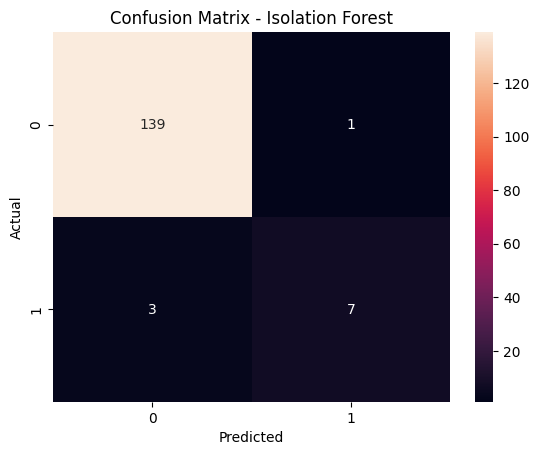

In [ ]:
# ============================================================
# STEP 10: Evaluate Isolation Forest
# ============================================================

evaluate_model(
    y_test,
    y_pred_iso,
    "Isolation Forest"
)


Model: Local Outlier Factor
Accuracy : 0.9866666666666667
Precision: 1.0
Recall   : 0.8
F1 Score : 0.8888888888888888

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       140
           1       1.00      0.80      0.89        10

    accuracy                           0.99       150
   macro avg       0.99      0.90      0.94       150
weighted avg       0.99      0.99      0.99       150



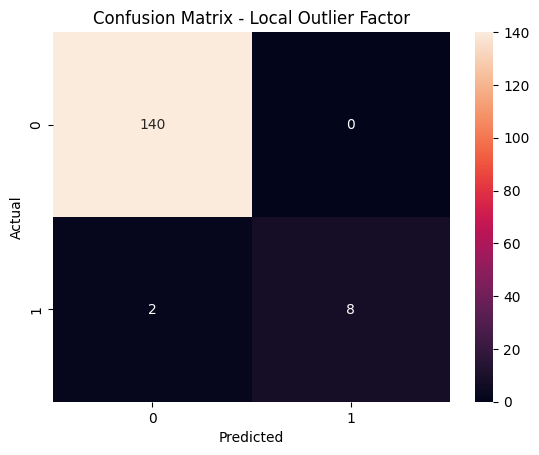

In [ ]:
# ============================================================
# STEP 11: Evaluate Local Outlier Factor
# ============================================================

evaluate_model(
    y_test,
    y_pred_lof,
    "Local Outlier Factor"
)



Model: One-Class SVM
Accuracy : 0.9133333333333333
Precision: 0.38461538461538464
Recall   : 0.5
F1 Score : 0.43478260869565216

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       140
           1       0.38      0.50      0.43        10

    accuracy                           0.91       150
   macro avg       0.67      0.72      0.69       150
weighted avg       0.92      0.91      0.92       150



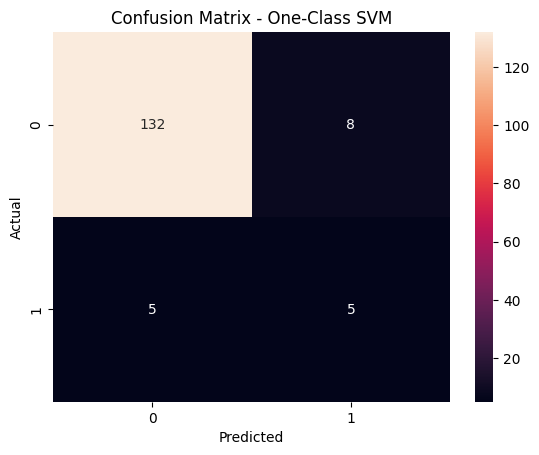

In [ ]:
# ============================================================
# STEP 12: Evaluate One-Class SVM
# ============================================================

evaluate_model(
    y_test,
    y_pred_svm,
    "One-Class SVM"
)

In [ ]:
# ============================================================
# STEP 13: Calculate ROC-AUC Scores
# ============================================================

print("\nROC-AUC Scores")

print("Isolation Forest:",
      roc_auc_score(y_test, y_pred_iso))

print("Local Outlier Factor:",
      roc_auc_score(y_test, y_pred_lof))

print("One-Class SVM:",
      roc_auc_score(y_test, y_pred_svm))



ROC-AUC Scores
Isolation Forest: 0.8464285714285714
Local Outlier Factor: 0.9
One-Class SVM: 0.7214285714285713


In [ ]:
# ============================================================
# STEP 14: Comparative Analysis Table
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Isolation Forest",
        "Local Outlier Factor",
        "One-Class SVM"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_iso),
        accuracy_score(y_test, y_pred_lof),
        accuracy_score(y_test, y_pred_svm)
    ],

    "Precision": [
        precision_score(y_test, y_pred_iso),
        precision_score(y_test, y_pred_lof),
        precision_score(y_test, y_pred_svm)
    ],

    "Recall": [
        recall_score(y_test, y_pred_iso),
        recall_score(y_test, y_pred_lof),
        recall_score(y_test, y_pred_svm)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_iso),
        f1_score(y_test, y_pred_lof),
        f1_score(y_test, y_pred_svm)
    ]
})

print("\nComparative Analysis:")
print(results)


Comparative Analysis:
                  Model  Accuracy  Precision  Recall  F1 Score
0      Isolation Forest  0.973333   0.875000     0.7  0.777778
1  Local Outlier Factor  0.986667   1.000000     0.8  0.888889
2         One-Class SVM  0.913333   0.384615     0.5  0.434783
